# PatchTST Stock Classifier for S&P 500 Stocks

This notebook mirrors the reference PatchTST pipeline, but adapts it for a classifier: for each context window, predict whether each of the next five trading days closes significantly lower, roughly flat, or significantly higher.

Data is loaded from a single panel CSV (`historic_data_rows.csv` by default) with a **sector** column. Set `SECTORS_TO_RUN` in the config cell: `None` for every sector in the file, or a list of exact sector strings from the CSV (the load cell prints the allowed labels).

The notebook compares two tracks:

- IBM Granite PatchTST zero-shot forecast baseline, then threshold forecasts into classes.
- A from-scratch **sector-scoped global** PatchTST classifier (all tickers in the selected sector subset).

Checkpoints and saved models are namespaced by a derived **artifact scope** slug (e.g. `information_technology` or `all_11_sectors`). Data must be provided as `historic_data_rows.csv` (see config).

Class IDs: `0 = down`, `1 = flat`, `2 = up`.

## 0. Environment Setup

Install from `requirements.txt` in a virtual environment or uncomment the `%pip` line below for a notebook-local install.

`peft` is included for parity with the IBM/LoRA reference workflow, but LoRA is not used by the from-scratch classifier. `bitsandbytes` is CUDA/Linux-only and is intentionally commented in `requirements.txt`.

In [1]:
# Uncomment to install inside the active notebook kernel.
# %pip install -r requirements.txt

import platform
from pathlib import Path

from numpy import float32

import torch

# ---- DEVICE / DTYPE CONFIG (override here to force a backend) ----
DEVICE_OVERRIDE = None   # None | 'cuda' | 'mps' | 'cpu'
DTYPE_OVERRIDE = 'float32'    # None | 'bfloat16' | 'float16' | 'float32'


def _autoselect_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def _autoselect_dtype(device):
    if device.type == 'cuda':
        return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    # MPS bf16 is flaky; CPU bf16 is slow and many ops fall back to fp32.
    return torch.float32


device = torch.device(DEVICE_OVERRIDE) if DEVICE_OVERRIDE else _autoselect_device()
dtype = getattr(torch, DTYPE_OVERRIDE) if DTYPE_OVERRIDE else _autoselect_dtype(device)
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4

print(f'New Zamn: OS={platform.system()} | device={device} | dtype={dtype} | workers={NUM_WORKERS}')

New Zamn: OS=Linux | device=cuda | dtype=torch.float32 | workers=4


In [2]:
import inspect
import os
import subprocess
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from transformers import EarlyStoppingCallback, PatchTSTConfig, TrainingArguments, Trainer

# ===== Environment Bootstrap =====
# On Kaggle: git-clone the repo so helper modules (.py files) are available,
# then point all paths at /kaggle/input and /kaggle/working.
# Locally: fall back to the repo-relative layout (WSL2 / macOS).

IS_KAGGLE = Path('/kaggle/input').exists()

if IS_KAGGLE:
    # Replace <owner> with your GitHub organisation/username.
    REPO_URL    = 'https://github.com/AntonyAPT/SeniorProject.git'
    # For a private repo, inject a PAT:
    #   from kaggle_secrets import UserSecretsClient
    #   pat = UserSecretsClient().get_secret('GITHUB_PAT')
    #   REPO_URL = f'https://{pat}@github.com/<owner>/SeniorProject.git'

    # Change REPO_BRANCH to your feature branch when running a sandbox kernel.
    REPO_BRANCH = 'feature/AntonyModel'

    REPO_DIR    = Path('/kaggle/working/SeniorProject')
    if not REPO_DIR.exists():
        subprocess.run(
            ['git', 'clone', '--depth', '1', '--branch', REPO_BRANCH, REPO_URL, str(REPO_DIR)],
            check=True,
        )
    NOTEBOOK_DIR   = REPO_DIR / 'models' / 'notebook'
    DATA_RAW_DIR = Path('/kaggle/input/datasets/kingz101/sp500-daily-raw')
    CHECKPOINT_DIR = Path('/kaggle/working/checkpoint/patchtst_cls')
    SAVE_DIR       = Path('/kaggle/working/save_dir')
else:
    # Local fallback (WSL2 / macOS — see README for setup).
    NOTEBOOK_DIR = Path.cwd()
    if NOTEBOOK_DIR.name != 'notebook':
        # Supports running from the repo root in VS Code/Cursor.
        NOTEBOOK_DIR = Path('models/notebook').resolve()
    DATA_RAW_DIR   = NOTEBOOK_DIR.parents[1] / 'models' / 'data_raw'
    CHECKPOINT_DIR = NOTEBOOK_DIR / 'checkpoint' / 'patchtst_cls'
    SAVE_DIR       = NOTEBOOK_DIR / 'save_dir'

sys.path.insert(0, str(NOTEBOOK_DIR))

from classification_head import PatchTSTClassifier
from dataset_utils import (
    StockWindowClassificationDataset,
    compute_class_weights,
    split_by_fraction,
    summarize_dataset,
)
from labeling import CLASS_NAMES, LabelConfig, make_class_labels

sns.set_theme(style='whitegrid')

Cloning into '/kaggle/working/SeniorProject'...


## 1. Notebook Configuration

The first block is the IBM Granite-compatible reference config. It stays commented because it is only used in the zero-shot baseline section.

The active block configures the from-scratch classifier. Labeling starts with a fixed ±1% threshold, but `LABEL_RULE` can later be changed to `rolling_vol` or `atr` without changing the model head.

In [3]:
# ---- IBM Granite-compatible config (IBM baseline only) ----
# GRANITE_BASE_MODEL = 'ibm-granite/granite-timeseries-patchtst'
# GRANITE_CONTEXT_LENGTH = 512
# GRANITE_PREDICTION_LENGTH = 96
# GRANITE_TARGET_COLUMNS = ['Close']

# ---- From-scratch classifier config ----
TIMESTAMP_COLUMN = 'Date'
TICKER_COLUMN = 'Ticker'
TARGET_COLUMNS = ['Open', 'High', 'Low', 'Close', 'Volume']
SECTOR_COLUMN = 'Sector'
ID_COLUMNS = ['Ticker', SECTOR_COLUMN]

# Panel file: models/data_raw/historic_data_rows.csv (required).
HISTORIC_CSV_FILENAME = 'historic_data_rows.csv'

# None = all sectors in the file; or e.g. ['Health Care', 'Energy'].
# Default: single-sector kernel — Information Technology (change list or set to None as needed).
SECTORS_TO_RUN = ['Information Technology']

CONTEXT_LENGTH = 128       # roughly six months of trading days
FORECAST_HORIZON = 5       # one trading week
PATCH_LENGTH = 8
PATCH_STRIDE = 8
BATCH_SIZE = 64
TRAIN_FRAC = 0.8
VALID_FRAC = 0.1
DATASET_NAME = 'sp500_daily'

# ---- Labeling hyperparameters ----
LABEL_RULE = 'fixed_pct'   # 'fixed_pct' | 'rolling_vol' | 'atr'
LABEL_THRESHOLD = 0.01     # 1% threshold for fixed_pct
VOL_WINDOW = 21
VOL_K = 0.5
N_CLASSES = 3

# ---- Training controls ----
GLOBAL_NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 3
RUN_GRANITE_BASELINE = False
RUN_GLOBAL_TRAINING = True

label_config = LabelConfig(
    rule=LABEL_RULE,
    threshold=LABEL_THRESHOLD,
    vol_window=VOL_WINDOW,
    vol_k=VOL_K,
)

print(label_config)
print('SECTORS_TO_RUN:', 'all sectors in file' if SECTORS_TO_RUN is None else SECTORS_TO_RUN)

LabelConfig(rule='fixed_pct', threshold=0.01, vol_window=21, vol_k=0.5)
SECTORS_TO_RUN: ['Information Technology']


## 2. Load & Preprocess CSV

Load **`historic_data_rows.csv`** only (long panel: date, ticker, OHLCV, sector). Column names are normalized to `Date, Ticker, Open, High, Low, Close, Volume, Sector` for the rest of the notebook.

After loading, rows are filtered by `SECTORS_TO_RUN`. `ARTIFACT_SCOPE_SLUG` and `RUN_SCOPE_DIR` isolate checkpoints and plots per sector scope.

Volume is log-transformed before scaling because it is orders of magnitude larger than OHLC prices. The notebook attempts to use IBM Granite TSFM's `TimeSeriesPreprocessor`; if that import/API is unavailable, it falls back to explicit **per-symbol** z-score scaling (normalization), not separate models per symbol.

Loaded historic panel from historic_data_rows.csv
Sector labels in CSV (must match SECTORS_TO_RUN strings exactly): ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']
artifact_scope=information_technology | rows=394434 | tickers=73 | sectors=1
Active sectors: ['Information Technology']
        Date Ticker      Open      High       Low     Close     Volume  \
0 2000-01-03   AAPL  0.785593  0.842710  0.761716  0.838496  20.099266   
1 2000-01-04   AAPL  0.810874  0.828664  0.757970  0.767802  20.054572   
2 2000-01-05   AAPL  0.777165  0.828196  0.771548  0.779038  20.472650   
3 2000-01-06   AAPL  0.794956  0.801510  0.711621  0.711621  20.459265   
4 2000-01-07   AAPL  0.722858  0.756566  0.715367  0.745330  19.948332   

                   Sector  
0  Information Technology  
1  Information Technology  
2  Information Technology  
3  Informatio

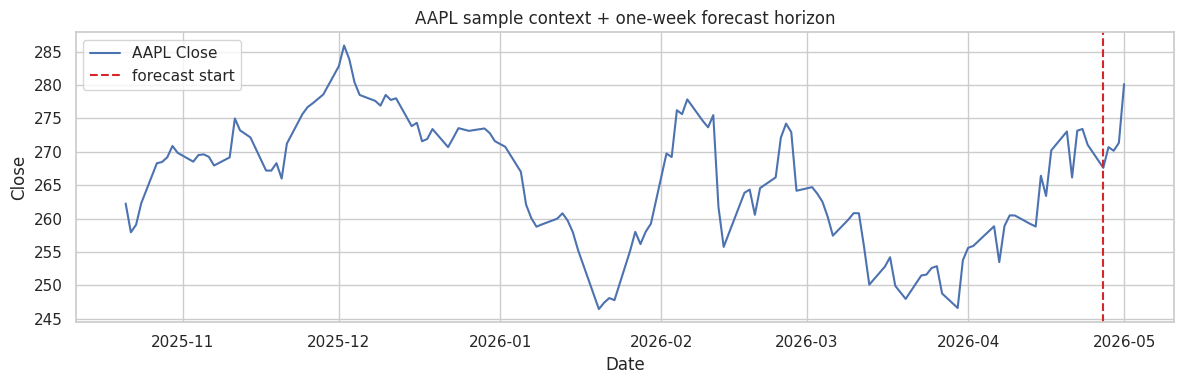

In [4]:
import re

HISTORIC_CSV_PATH = DATA_RAW_DIR / HISTORIC_CSV_FILENAME


def _sector_slug(name: str) -> str:
    s = re.sub(r'[^a-zA-Z0-9]+', '_', str(name).strip().lower()).strip('_')
    return s or 'unknown'


def _build_artifact_scope_slug(active_sectors: list[str]) -> str:
    if len(active_sectors) == 1:
        return _sector_slug(active_sectors[0])
    return f'all_{len(active_sectors)}_sectors'


_CANONICAL_LOWER = {
    'date': TIMESTAMP_COLUMN,
    'ticker': TICKER_COLUMN,
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume',
    'sector': SECTOR_COLUMN,
}


def _normalize_historic_columns(frame: pd.DataFrame) -> pd.DataFrame:
    rename = {}
    for c in frame.columns:
        key = str(c).strip().lower()
        if key in _CANONICAL_LOWER:
            rename[c] = _CANONICAL_LOWER[key]
    out = frame.rename(columns=rename)
    if TIMESTAMP_COLUMN not in out.columns:
        raise ValueError(f'Expected a date column; got columns={list(frame.columns)}')
    out[TIMESTAMP_COLUMN] = pd.to_datetime(out[TIMESTAMP_COLUMN])
    return out


if not HISTORIC_CSV_PATH.exists():
    raise FileNotFoundError(
        f'Missing {HISTORIC_CSV_PATH}. Place {HISTORIC_CSV_FILENAME} under {DATA_RAW_DIR.resolve()}.'
    )

raw_df = _normalize_historic_columns(pd.read_csv(HISTORIC_CSV_PATH))
print(f'Loaded historic panel from {HISTORIC_CSV_PATH.name}')

if SECTOR_COLUMN not in raw_df.columns:
    raise ValueError(f'Expected a {SECTOR_COLUMN!r} column after normalization; columns={list(raw_df.columns)}')

available_sectors = sorted(str(s) for s in raw_df[SECTOR_COLUMN].dropna().unique())
print('Sector labels in CSV (must match SECTORS_TO_RUN strings exactly):', available_sectors)
if SECTORS_TO_RUN is None:
    active_sectors = available_sectors
else:
    missing = sorted(set(SECTORS_TO_RUN) - set(available_sectors))
    if missing:
        raise ValueError(
            f'SECTORS_TO_RUN has unknown sectors {missing}. '
            f'Available in data: {available_sectors}'
        )
    active_sectors = list(SECTORS_TO_RUN)

raw_df = raw_df.loc[raw_df[SECTOR_COLUMN].isin(active_sectors)].copy()
raw_df = raw_df.sort_values([TICKER_COLUMN, TIMESTAMP_COLUMN]).reset_index(drop=True)
raw_df[TICKER_COLUMN] = raw_df[TICKER_COLUMN].astype(str)
raw_df[SECTOR_COLUMN] = raw_df[SECTOR_COLUMN].astype(str)
raw_df['Volume'] = np.log1p(raw_df['Volume'].astype(float))

ARTIFACT_SCOPE_SLUG = _build_artifact_scope_slug(active_sectors)
RUN_SCOPE_DIR = CHECKPOINT_DIR / ARTIFACT_SCOPE_SLUG
RUN_SCOPE_DIR.mkdir(parents=True, exist_ok=True)
DATASET_RUN_LABEL = f'{DATASET_NAME}_sector_{ARTIFACT_SCOPE_SLUG}'

print(
    f'artifact_scope={ARTIFACT_SCOPE_SLUG} | rows={len(raw_df)} | '
    f'tickers={raw_df[TICKER_COLUMN].nunique()} | sectors={len(active_sectors)}'
)
print('Active sectors:', active_sectors)
print(raw_df.head())
print(raw_df.groupby(TICKER_COLUMN).size().head(20))

# Sample weekly-ish context plot, matching the spirit of the reference notebook.
sample_ticker = raw_df[TICKER_COLUMN].iloc[0]
sample = raw_df[raw_df[TICKER_COLUMN] == sample_ticker].tail(CONTEXT_LENGTH + FORECAST_HORIZON)
plt.figure(figsize=(12, 4))
plt.plot(sample[TIMESTAMP_COLUMN], sample['Close'], label=f'{sample_ticker} Close')
plt.axvline(sample[TIMESTAMP_COLUMN].iloc[-FORECAST_HORIZON], color='tab:red', linestyle='--', label='forecast start')
plt.title(f'{sample_ticker} sample context + one-week forecast horizon')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def manual_per_ticker_standardize(train_df, valid_df, test_df, target_columns, ticker_column='Ticker'):
    stats = {}
    for ticker, group in train_df.groupby(ticker_column):
        mean = group[target_columns].astype(float).mean()
        std = group[target_columns].astype(float).std().replace(0, 1.0).fillna(1.0)
        stats[str(ticker)] = (mean, std)

    global_mean = train_df[target_columns].astype(float).mean()
    global_std = train_df[target_columns].astype(float).std().replace(0, 1.0).fillna(1.0)

    def transform(frame):
        frame = frame.copy()
        for ticker, idx in frame.groupby(ticker_column).groups.items():
            mean, std = stats.get(str(ticker), (global_mean, global_std))
            frame.loc[idx, target_columns] = (frame.loc[idx, target_columns].astype(float) - mean) / std
        return frame

    return transform(train_df), transform(valid_df), transform(test_df), stats


def try_granite_preprocess(train_df, valid_df, test_df):
    try:
        from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
    except Exception as exc:
        print(f'Granite TimeSeriesPreprocessor unavailable; using manual scaler. Reason: {exc}')
        return (*manual_per_ticker_standardize(train_df, valid_df, test_df, TARGET_COLUMNS, TICKER_COLUMN), None)

    try:
        tsp = TimeSeriesPreprocessor(
            timestamp_column=TIMESTAMP_COLUMN,
            id_columns=ID_COLUMNS,
            target_columns=TARGET_COLUMNS,
            scaling='std',
        )
        tsp.train(train_df)

        def transform(frame):
            if hasattr(tsp, 'preprocess'):
                return tsp.preprocess(frame)
            if hasattr(tsp, 'transform'):
                return tsp.transform(frame)
            return tsp(frame)

        return transform(train_df), transform(valid_df), transform(test_df), None, tsp
    except Exception as exc:
        print(f'Granite preprocessing failed; using manual scaler. Reason: {exc}')
        return (*manual_per_ticker_standardize(train_df, valid_df, test_df, TARGET_COLUMNS, TICKER_COLUMN), None)


train_raw, valid_raw, test_raw = split_by_fraction(
    raw_df,
    train_frac=TRAIN_FRAC,
    valid_frac=VALID_FRAC,
    timestamp_column=TIMESTAMP_COLUMN,
    ticker_column=TICKER_COLUMN,
    context_length=CONTEXT_LENGTH,
)

train_values, valid_values, test_values, scaler_stats, tsp = try_granite_preprocess(train_raw, valid_raw, test_raw)

train_ds = StockWindowClassificationDataset(train_values, train_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON, label_config)
valid_ds = StockWindowClassificationDataset(valid_values, valid_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON, label_config)
test_ds = StockWindowClassificationDataset(test_values, test_raw, TARGET_COLUMNS, CONTEXT_LENGTH, FORECAST_HORIZON, label_config)

dataset_summary = pd.concat([
    summarize_dataset('train', train_ds),
    summarize_dataset('valid', valid_ds),
    summarize_dataset('test', test_ds),
], ignore_index=True)
dataset_summary

Granite TimeSeriesPreprocessor unavailable; using manual scaler. Reason: No module named 'tsfm_public'


,dataset,windows,down,flat,up,down_pct,flat_pct,up_pct
0,train,305905,500443,442499,586583,0.327189,0.289305,0.383507
1,valid,39131,66170,54141,75344,0.338197,0.276717,0.385086
2,test,39189,63385,56110,76450,0.323484,0.286356,0.390161


### Optional Granite Padding

Granite's published PatchTST checkpoint expects a longer context than the from-scratch classifier. Use this only in the IBM baseline path when a series does not have enough context. For the included raw datasets, each ticker has enough history.

In [6]:
# Optional, IBM-config only:
# from ts_padding_utils import pad_batch_for_granite
# padded_batch = pad_batch_for_granite(batch, context_length=512)

## 3-4. Label Generation, Metrics, and Visualization

Labels are generated inside `StockWindowClassificationDataset` from original close prices. The model sees scaled OHLCV values, but the class target is always based on the unscaled close move from the final context day to each future day.

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)

    flat_preds = preds.reshape(-1)
    flat_labels = labels.reshape(-1)

    metrics = {
        'accuracy': accuracy_score(flat_labels, flat_preds),
        'macro_f1': f1_score(flat_labels, flat_preds, average='macro', labels=[0, 1, 2], zero_division=0),
    }

    for day_idx in range(labels.shape[1]):
        metrics[f'day_{day_idx + 1}_accuracy'] = accuracy_score(labels[:, day_idx], preds[:, day_idx])

    per_class = f1_score(flat_labels, flat_preds, average=None, labels=[0, 1, 2], zero_division=0)
    for class_id, score in enumerate(per_class):
        metrics[f'{CLASS_NAMES[class_id]}_f1'] = score

    return metrics


def confusion_matrices_by_day(labels, preds):
    matrices = []
    for day_idx in range(labels.shape[1]):
        matrices.append(confusion_matrix(labels[:, day_idx], preds[:, day_idx], labels=[0, 1, 2]))
    return matrices


def evaluate_logits(logits, labels, name='model'):
    preds = np.argmax(logits, axis=-1)
    metrics = compute_metrics((logits, labels))
    print(f"{name} accuracy={metrics['accuracy']:.4f} macro_f1={metrics['macro_f1']:.4f}")
    return metrics, preds

In [8]:
def trainer_predict_logits(trainer, dataset):
    output = trainer.predict(dataset)
    logits = output.predictions[0] if isinstance(output.predictions, tuple) else output.predictions
    return logits, output.label_ids


def plot_window_predictions(
    raw_df,
    metadata,
    actual_labels,
    predicted_labels,
    *,
    ticker_column=TICKER_COLUMN,
    timestamp_column=TIMESTAMP_COLUMN,
    price_column='Close',
    title=None,
):
    """Overlay per-day up/flat/down predictions on the stock's close-price chart.

    Draws the context window as a continuous price line, marks the forecast
    boundary with a dashed vertical line, and annotates each forecast day with
    a directional arrow (↑ up / → flat / ↓ down).

    Arrow color: green = prediction was correct, red = prediction was wrong.
    When wrong, the actual direction is added as a small grey label below the dot.
    """
    arrow_for = {0: '↓', 1: '→', 2: '↑'}
    color_for = {0: 'tab:red', 1: 'tab:gray', 2: 'tab:green'}

    window = raw_df[
        (raw_df[ticker_column] == metadata.ticker)
        & (raw_df[timestamp_column] >= metadata.context_start)
        & (raw_df[timestamp_column] <= metadata.forecast_end)
    ].sort_values(timestamp_column)

    forecast_window = window[window[timestamp_column] >= metadata.forecast_start]
    forecast_dates = forecast_window[timestamp_column].tolist()
    forecast_prices = forecast_window[price_column].tolist()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(window[timestamp_column], window[price_column],
            color='black', linewidth=1.2, label=f'{metadata.ticker} Close')
    ax.axvline(metadata.forecast_start, color='tab:blue',
               linestyle='--', alpha=0.6, label='Forecast start')

    price_range = (max(forecast_prices) - min(forecast_prices)) if forecast_prices else 1.0
    offset = max(price_range, 1e-6) * 0.35

    for i, (date, price) in enumerate(zip(forecast_dates, forecast_prices)):
        if i >= len(predicted_labels):
            break
        pred = int(predicted_labels[i])
        actual = int(actual_labels[i])
        correct = (pred == actual)

        ax.annotate(
            arrow_for[pred],
            xy=(date, price),
            xytext=(date, price + offset),
            ha='center', va='bottom',
            fontsize=22, fontweight='bold',
            color=color_for[pred] if correct else 'tab:red',
        )
        ax.scatter([date], [price],
                   color='tab:green' if correct else 'tab:red',
                   s=60, zorder=5, edgecolor='black', linewidth=0.5)

        if not correct:
            ax.annotate(
                f'actual: {arrow_for[actual]}',
                xy=(date, price),
                xytext=(date, price - offset * 0.55),
                ha='center', va='top',
                fontsize=9, color='gray',
            )

    ax.set_title(title or (
        f'{metadata.ticker} — context {metadata.context_start.date()} '
        f'to {metadata.context_end.date()}, '
        f'predict next {len(predicted_labels)} day(s)'
    ))
    ax.set_xlabel('Date')
    ax.set_ylabel(price_column)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def evaluate_and_visualize(model_or_trainer, dataset, name='model', sample_idx=0):
    if isinstance(model_or_trainer, Trainer):
        logits, labels = trainer_predict_logits(model_or_trainer, dataset)
    else:
        loader = DataLoader(dataset, batch_size=BATCH_SIZE)
        logits_batches, label_batches = [], []
        model_or_trainer.eval()
        model_or_trainer.to(device)
        with torch.no_grad():
            for batch in loader:
                model_dtype = next(model_or_trainer.parameters()).dtype
                past_values = batch['past_values'].to(device=device, dtype=model_dtype)
                outputs = model_or_trainer(past_values=past_values)
                logits_batches.append(outputs.logits.detach().cpu().float().numpy())
                label_batches.append(batch['labels'].numpy())
        logits = np.concatenate(logits_batches, axis=0)
        labels = np.concatenate(label_batches, axis=0)

    metrics, preds = evaluate_logits(logits, labels, name=name)

    fig, axes = plt.subplots(1, FORECAST_HORIZON, figsize=(4 * FORECAST_HORIZON, 3), sharey=True)
    if FORECAST_HORIZON == 1:
        axes = [axes]
    matrices = confusion_matrices_by_day(labels, preds)
    for day_idx, (ax, matrix) in enumerate(zip(axes, matrices), start=1):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['down', 'flat', 'up'], yticklabels=['down', 'flat', 'up'])
        ax.set_title(f'Day {day_idx}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    fig.suptitle(f'{name} confusion matrices')
    plt.tight_layout()
    plt.show()

    per_day = [metrics[f'day_{idx + 1}_accuracy'] for idx in range(FORECAST_HORIZON)]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=[f'Day {idx + 1}' for idx in range(FORECAST_HORIZON)], y=per_day)
    plt.ylim(0, 1)
    plt.title(f'{name} per-day accuracy')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

    sample_idx = min(sample_idx, len(labels) - 1)
    sample_meta = dataset.metadata(sample_idx) if hasattr(dataset, 'metadata') else None
    sample_df = pd.DataFrame({
        'day': [f'Day {idx + 1}' for idx in range(FORECAST_HORIZON)],
        'actual': [CLASS_NAMES[int(x)] for x in labels[sample_idx]],
        'predicted': [CLASS_NAMES[int(x)] for x in preds[sample_idx]],
    })
    if sample_meta is not None:
        plot_window_predictions(
            raw_df,
            sample_meta,
            actual_labels=labels[sample_idx],
            predicted_labels=preds[sample_idx],
            title=f'{name} — {sample_meta.ticker} sample window',
        )
    display(sample_df)

    return {'metrics': metrics, 'predictions': preds, 'labels': labels, 'logits': logits}

## 5. IBM Granite Zero-Shot Baseline (IBM-Config Only)

This section uses `ibm-granite/granite-timeseries-patchtst` as a domain-shifted zero-shot forecaster. Granite was not trained on stock OHLCV data, so this is a baseline comparison rather than the primary model.

The model forecasts continuous closes. We convert the first five forecasted closes into up/flat/down classes using the exact same label rule as the trained classifier.

In [9]:
def _prediction_array(outputs):
    for attr in ('prediction_outputs', 'prediction_logits', 'logits'):
        if hasattr(outputs, attr) and getattr(outputs, attr) is not None:
            value = getattr(outputs, attr)
            return value[0] if isinstance(value, tuple) else value
    if isinstance(outputs, tuple):
        return outputs[0]
    raise RuntimeError('Could not locate prediction tensor in Granite output.')


def run_granite_zero_shot_baseline():
    from transformers import PatchTSTForPrediction

    GRANITE_BASE_MODEL = 'ibm-granite/granite-timeseries-patchtst'
    GRANITE_CONTEXT_LENGTH = 512
    GRANITE_TARGET_COLUMNS = ['Close']

    granite_test = StockWindowClassificationDataset(
        values_df=test_raw[[TIMESTAMP_COLUMN, TICKER_COLUMN, 'Close']].copy(),
        label_df=test_raw.copy(),
        target_columns=GRANITE_TARGET_COLUMNS,
        context_length=GRANITE_CONTEXT_LENGTH,
        forecast_horizon=FORECAST_HORIZON,
        label_config=label_config,
    )
    print(f'Granite baseline windows: {len(granite_test)}')

    model = PatchTSTForPrediction.from_pretrained(GRANITE_BASE_MODEL).to(device)
    model.eval()

    all_preds, all_labels = [], []
    loader = DataLoader(granite_test, batch_size=min(BATCH_SIZE, 32), num_workers=NUM_WORKERS)
    with torch.no_grad():
        for batch in loader:
            past_values = batch['past_values'].to(device=device, dtype=torch.float32)
            # Granite expects 7 channels; repeat Close across all 7
            past_values = past_values.expand(-1, -1, 7)   # (B, T, 1) → (B, T, 7)
            outputs = model(past_values=past_values)
            forecasts = _prediction_array(outputs).detach().cpu().numpy()
            forecasts = forecasts[:, :FORECAST_HORIZON, 0] if forecasts.ndim == 3 else forecasts[:, :FORECAST_HORIZON]
            anchors = batch['past_values'][:, -1, 0].detach().cpu().numpy()
            pred_labels = make_class_labels(
                future_close=forecasts,
                past_close_t=anchors,
                rule=LABEL_RULE,
                threshold=LABEL_THRESHOLD,
                vol_window=VOL_WINDOW,
                vol_k=VOL_K,
            )
            all_preds.append(pred_labels)
            all_labels.append(batch['labels'].numpy())

    preds = np.concatenate(all_preds, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    logits = np.eye(N_CLASSES)[preds]
    metrics, _ = evaluate_logits(logits, labels, name='IBM Granite zero-shot')
    return {'metrics': metrics, 'predictions': preds, 'labels': labels, 'logits': logits}


granite_results = None
if RUN_GRANITE_BASELINE:
    try:
        granite_results = run_granite_zero_shot_baseline()
    except Exception as exc:
        print(f'Granite baseline skipped: {exc}')
else:
    print('Granite baseline disabled by RUN_GRANITE_BASELINE=False')

Granite baseline disabled by RUN_GRANITE_BASELINE=False


## 6. From-Scratch PatchTST Classifier — Global Model

This model trains across **all tickers in the current sector scope** (see `SECTORS_TO_RUN` and `ARTIFACT_SCOPE_SLUG`) using the same PatchTST encoder family, but with a custom multi-day classification head instead of the forecasting head.

TensorBoard logs are written under `./checkpoint/patchtst_cls/<artifact_scope>/global/logs/...`.

Class weights: [1.0053294  1.1369745  0.85769624]


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
2026-05-03 21:01:23.317634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777842083.752642      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777842083.855483      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777842084.808765      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777842084.808793      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target 

Training global PatchTST classifier on sp500_daily_sector_information_technology


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Day 1 Accuracy,Day 2 Accuracy,Day 3 Accuracy,Day 4 Accuracy,Day 5 Accuracy,Down F1,Flat F1,Up F1
1,2.137317,2.153397,0.402193,0.399527,0.426848,0.362194,0.381794,0.412128,0.427998,0.338632,0.430379,0.429570
2,2.122015,2.153723,0.406879,0.403237,0.429429,0.365771,0.394240,0.414301,0.430656,0.337508,0.431961,0.440243
3,2.107147,2.150640,0.405965,0.406373,0.433748,0.375738,0.383226,0.405484,0.431627,0.385416,0.430388,0.403316
4,2.091606,2.159464,0.402668,0.397692,0.434719,0.368966,0.382331,0.401446,0.425877,0.327866,0.442994,0.422217
5,2.075428,2.159798,0.406210,0.405986,0.436457,0.377016,0.388490,0.404283,0.424804,0.381736,0.440016,0.396206
6,2.059526,2.156756,0.414480,0.414102,0.436278,0.386267,0.401906,0.417188,0.430758,0.387482,0.423075,0.431751
7,2.043931,2.158446,0.413478,0.413871,0.436559,0.382254,0.398661,0.416473,0.433442,0.399346,0.429101,0.413165
8,2.028493,2.160155,0.419243,0.417382,0.438578,0.387647,0.405970,0.422989,0.441031,0.376018,0.428210,0.447919
9,2.015407,2.164155,0.417725,0.416281,0.439881,0.390304,0.403593,0.417367,0.437479,0.378233,0.427569,0.443042
10,2.004060,2.165408,0.418083,0.417621,0.439115,0.389129,0.403644,0.420741,0.437786,0.390434,0.428356,0.434072


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

global PatchTST classifier [information_technology] accuracy=0.3939 macro_f1=0.3930


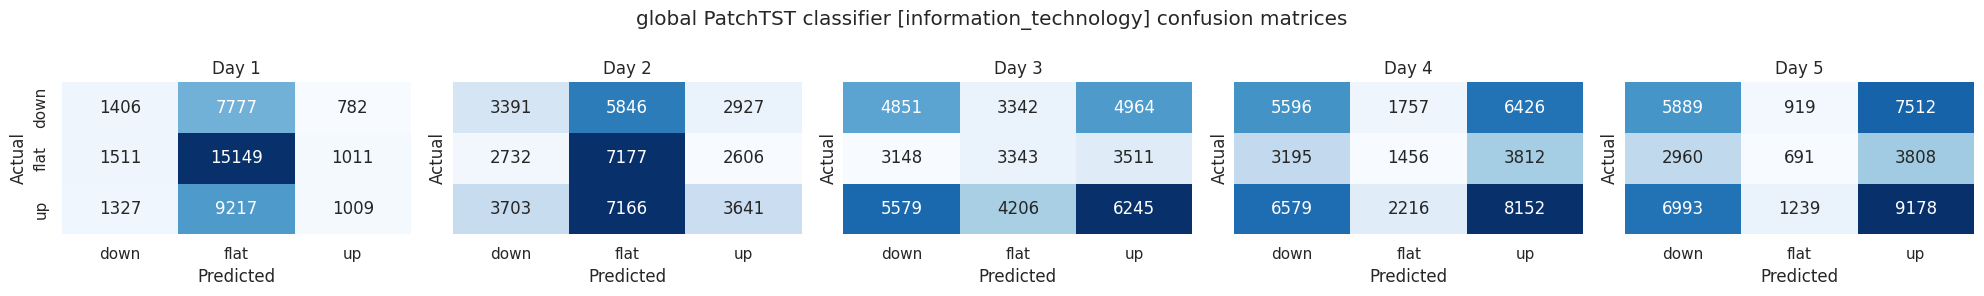

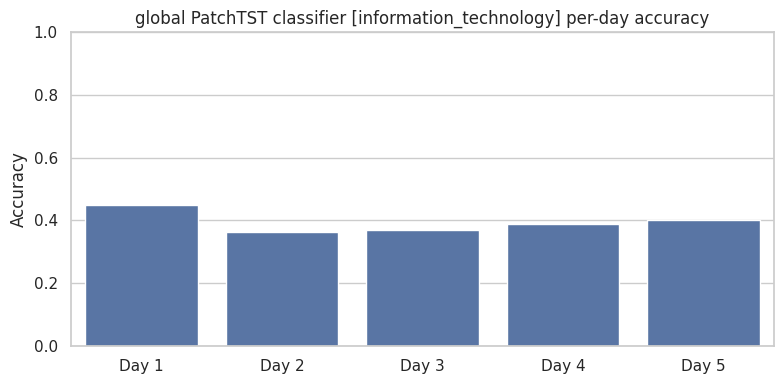

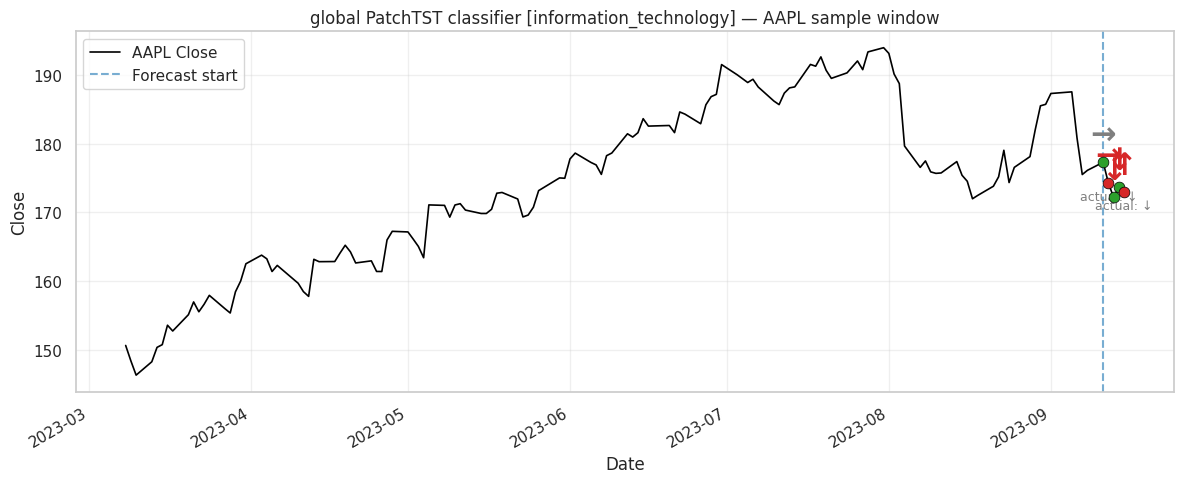

,day,actual,predicted
0,Day 1,flat,flat
1,Day 2,down,flat
2,Day 3,down,down
3,Day 4,down,down
4,Day 5,down,up


In [10]:
def make_patchtst_config(context_length=CONTEXT_LENGTH, num_input_channels=None):
    return PatchTSTConfig(
        do_mask_input=False,
        context_length=context_length,
        patch_length=PATCH_LENGTH,
        patch_stride=PATCH_STRIDE,
        num_input_channels=num_input_channels or len(TARGET_COLUMNS),
        prediction_length=FORECAST_HORIZON,
        d_model=128,
        num_attention_heads=16,
        num_hidden_layers=3,
        ffn_dim=512,
        dropout=0.2,
        head_dropout=0.2,
        pooling_type=None,
        channel_attention=False,
        scaling='std',
        loss='ce',
        pre_norm=True,
        norm_type='batchnorm',
    )


def make_training_args(output_dir, logging_dir, num_epochs):
    params = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = dict(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        dataloader_num_workers=NUM_WORKERS,
        save_strategy='epoch',
        logging_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='eval_macro_f1',
        greater_is_better=True,
        logging_dir=str(logging_dir),
        report_to='tensorboard',
        label_names=['labels'],
        remove_unused_columns=False,
        fp16=(dtype == torch.float16 and device.type == 'cuda'),
        bf16=(dtype == torch.bfloat16 and device.type == 'cuda'),
    )
    kwargs['eval_strategy' if 'eval_strategy' in params else 'evaluation_strategy'] = 'epoch'
    if 'use_cpu' in params:
        kwargs['use_cpu'] = device.type == 'cpu'
    elif 'no_cuda' in params:
        kwargs['no_cuda'] = device.type != 'cuda'
    return TrainingArguments(**kwargs)


class_weights = compute_class_weights(train_ds).to(device)
print('Class weights:', class_weights.detach().cpu().numpy())

global_config = make_patchtst_config(num_input_channels=len(TARGET_COLUMNS))
global_model = PatchTSTClassifier(
    config=global_config,
    horizon=FORECAST_HORIZON,
    n_classes=N_CLASSES,
    class_weights=class_weights,
).to(device=device, dtype=dtype if device.type == 'cuda' else torch.float32)

global_output_dir = RUN_SCOPE_DIR / 'global' / 'output'
global_logging_dir = RUN_SCOPE_DIR / 'global' / 'logs' / datetime.now().strftime('%Y%m%d_%H%M%S')

global_trainer = Trainer(
    model=global_model,
    args=make_training_args(global_output_dir, global_logging_dir, GLOBAL_NUM_EPOCHS),
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

global_results = None
if RUN_GLOBAL_TRAINING:
    print(f'Training global PatchTST classifier on {DATASET_RUN_LABEL}')
    global_trainer.train()
    global_results = evaluate_and_visualize(
        global_trainer,
        test_ds,
        name=f'global PatchTST classifier [{ARTIFACT_SCOPE_SLUG}]',
    )
else:
    print('Global training disabled by RUN_GLOBAL_TRAINING=False')

In [11]:
# Sanity check: prediction logits should be (num_windows, 5, 3).
if RUN_GLOBAL_TRAINING and global_results is not None:
    print(global_results['logits'].shape)
else:
    sample_batch = next(iter(DataLoader(test_ds, batch_size=4)))
    global_model.eval()
    with torch.no_grad():
        sample_outputs = global_model(past_values=sample_batch['past_values'].to(device))
    print(sample_outputs.logits.shape)

(39189, 5, 3)


## 7. Training scope

Training is **per sector scope** only: one global PatchTST classifier over all tickers that remain after `SECTORS_TO_RUN` (see section 6). There is no per-ticker model loop.

In [12]:
# Per-ticker training removed; sector-scoped global model is the only trained classifier path.

## 8. Comparison & Visualization

Compare IBM Granite zero-shot and the sector-scoped global PatchTST classifier.

,model_group,accuracy_mean,accuracy_min,accuracy_max,macro_f1_mean,macro_f1_min,macro_f1_max,n_models
0,trained_global,0.393855,0.393855,0.393855,0.393046,0.393046,0.393046,1


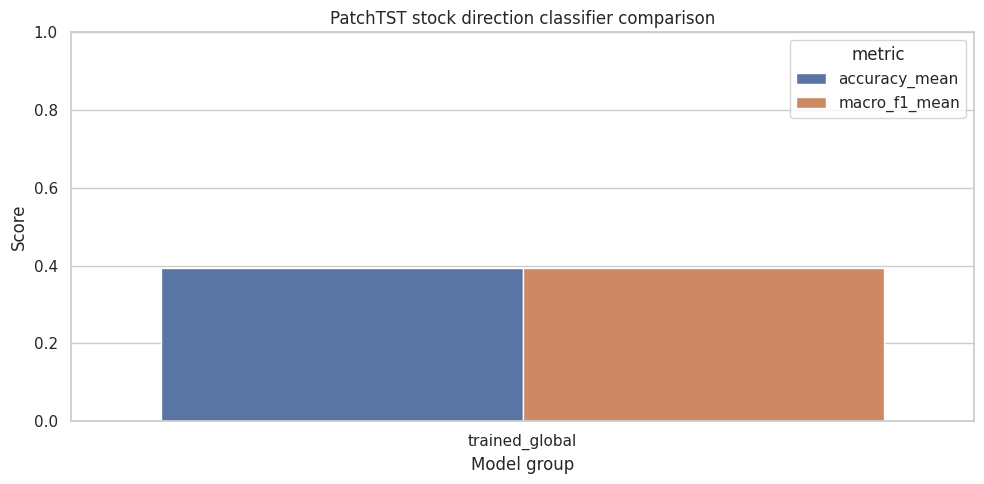

Saved comparison plot to /kaggle/working/checkpoint/patchtst_cls/information_technology/model_comparison.png


In [13]:
comparison_rows = []

if granite_results is not None:
    comparison_rows.append({
        'model': 'IBM Granite zero-shot',
        'accuracy': granite_results['metrics']['accuracy'],
        'macro_f1': granite_results['metrics']['macro_f1'],
        'kind': 'baseline',
    })

if global_results is not None:
    comparison_rows.append({
        'model': 'Global PatchTST classifier',
        'accuracy': global_results['metrics']['accuracy'],
        'macro_f1': global_results['metrics']['macro_f1'],
        'kind': 'trained_global',
    })

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    print('No completed model results yet. Run at least one baseline/training section first.')
else:
    summary_rows = []
    for kind, group in comparison_df.groupby('kind'):
        summary_rows.append({
            'model_group': kind,
            'accuracy_mean': group['accuracy'].mean(),
            'accuracy_min': group['accuracy'].min(),
            'accuracy_max': group['accuracy'].max(),
            'macro_f1_mean': group['macro_f1'].mean(),
            'macro_f1_min': group['macro_f1'].min(),
            'macro_f1_max': group['macro_f1'].max(),
            'n_models': len(group),
        })
    comparison_summary = pd.DataFrame(summary_rows)
    display(comparison_summary)

    plot_df = comparison_summary.melt(
        id_vars=['model_group'],
        value_vars=['accuracy_mean', 'macro_f1_mean'],
        var_name='metric',
        value_name='score',
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x='model_group', y='score', hue='metric')
    plt.ylim(0, 1)
    plt.title('PatchTST stock direction classifier comparison')
    plt.xlabel('Model group')
    plt.ylabel('Score')
    plt.tight_layout()
    comparison_plot_path = RUN_SCOPE_DIR / 'model_comparison.png'
    comparison_plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(comparison_plot_path, dpi=160)
    plt.show()
    print(f'Saved comparison plot to {comparison_plot_path}')

## 9. Save Model/Adapter & Optional Push to Hub

The from-scratch model is saved locally. Publishing to Hugging Face is optional and remains commented out.

In [14]:
global_save_dir = SAVE_DIR / f'patchtst_cls_sector_{ARTIFACT_SCOPE_SLUG}'
global_save_dir.mkdir(parents=True, exist_ok=True)

if global_model is not None:
    torch.save(global_model.state_dict(), global_save_dir / 'pytorch_model.bin')
    global_config.save_pretrained(global_save_dir)
    pd.Series({
        'context_length': CONTEXT_LENGTH,
        'forecast_horizon': FORECAST_HORIZON,
        'label_rule': LABEL_RULE,
        'label_threshold': LABEL_THRESHOLD,
        'target_columns': ','.join(TARGET_COLUMNS),
        'artifact_scope_slug': ARTIFACT_SCOPE_SLUG,
        'sectors': ','.join(active_sectors),
    }).to_json(global_save_dir / 'training_metadata.json', indent=2)
    print('Model saved to', global_save_dir.resolve())

# Optional - requires `huggingface-cli login` or `from huggingface_hub import login; login()`.
# Because PatchTSTClassifier is a local wrapper class, prefer uploading the full
# folder with README + source files rather than calling model.push_to_hub directly.
# from huggingface_hub import HfApi
# HfApi().upload_folder(
#     folder_path=str(global_save_dir),
#     repo_id='your-username/patchtst-stock-classifier',
#     repo_type='model',
# )

Model saved to /kaggle/working/save_dir/patchtst_cls_sector_information_technology


## 10. Re-Evaluate Fine-Tuned Model

Reload the saved global classifier from disk and re-run the evaluation visualization to verify the checkpoint works.

reloaded global PatchTST classifier accuracy=0.3939 macro_f1=0.3930


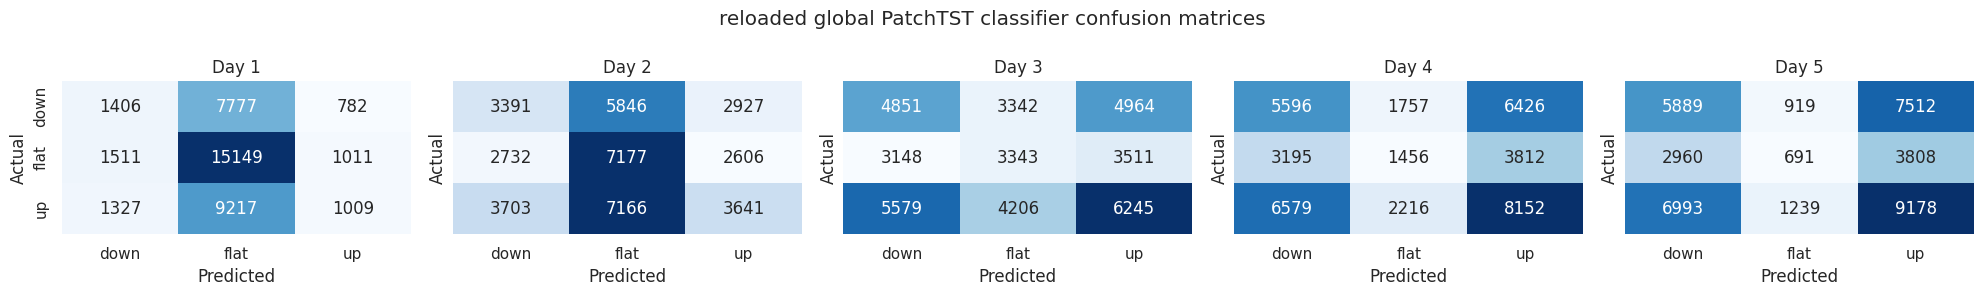

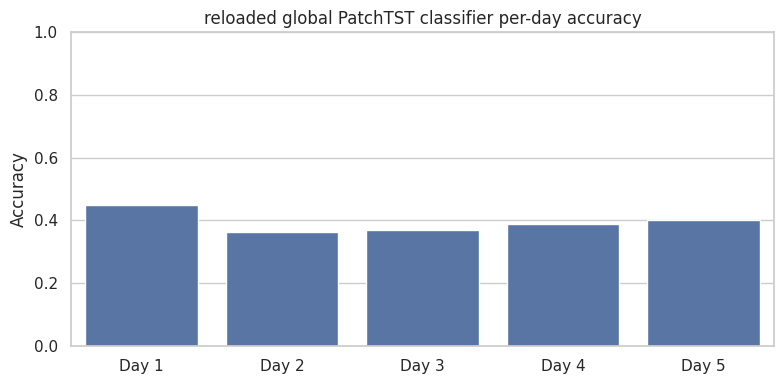

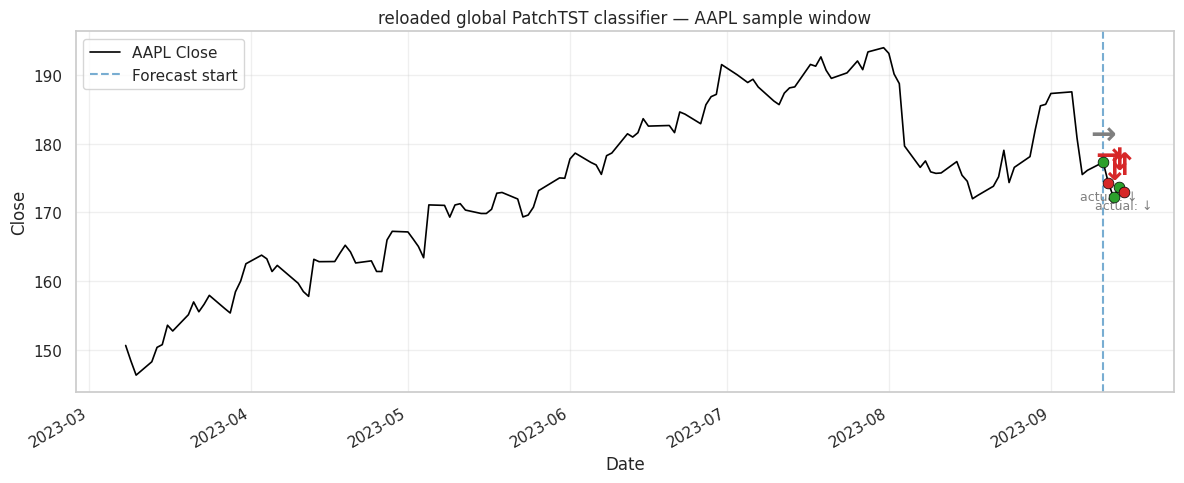

,day,actual,predicted
0,Day 1,flat,flat
1,Day 2,down,flat
2,Day 3,down,down
3,Day 4,down,down
4,Day 5,down,up


In [15]:
reloaded_results = None
checkpoint_path = global_save_dir / 'pytorch_model.bin'
if checkpoint_path.exists():
    reloaded_config = PatchTSTConfig.from_pretrained(global_save_dir)
    reloaded_model = PatchTSTClassifier(
        config=reloaded_config,
        horizon=FORECAST_HORIZON,
        n_classes=N_CLASSES,
        class_weights=class_weights.detach().cpu(),
    )
    # Materialize LazyLinear before loading the saved classifier head weights.
    sample_batch = next(iter(DataLoader(test_ds, batch_size=1)))
    with torch.no_grad():
        _ = reloaded_model(past_values=sample_batch['past_values'])
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    reloaded_model.load_state_dict(state_dict)
    reloaded_model.to(device=device, dtype=dtype if device.type == 'cuda' else torch.float32)
    reloaded_results = evaluate_and_visualize(reloaded_model, test_ds, name='reloaded global PatchTST classifier')
else:
    print(f'No saved checkpoint found at {checkpoint_path}. Run the save cell first.')

## TensorBoard

Run this from `models/notebook` after training starts. Logs live under `./checkpoint/patchtst_cls/<artifact_scope>/global/logs/` (use your current `ARTIFACT_SCOPE_SLUG`, or point at the parent to see all runs):

```bash
tensorboard --logdir ./checkpoint/patchtst_cls/
```

Then open the printed local URL in your browser.

### Save run to Github Branch
The following cells save successful runs to a specified Github branch, assuming the developer has a GitHub token saved in their Kaggle Account

Steps: 
1. Go to Kaggle → Settings → Secrets → Add secret named GITHUB_TOKEN
2. Access it in the notebook:

In [16]:
# import os
# from pathlib import Path

# from dotenv import load_dotenv


# def _load_local_env() -> None:
#     # Typical: cwd is repo root, or models/notebook
#     for root in (Path.cwd(), Path.cwd() / "models" / "notebook"):
#         for name in (".env.local", ".env"):
#             p = root / name
#             if p.is_file():
#                 load_dotenv(p)
#                 return


# def get_github_token() -> str:
#     token = os.getenv("GITHUB_TOKEN")
#     if token:
#         return token
#     _load_local_env()
#     token = os.getenv("GITHUB_TOKEN")
#     if token:
#         return token
#     from kaggle_secrets import UserSecretsClient

#     return UserSecretsClient().get_secret("GITHUB_TOKEN")


# token = get_github_token()

In [17]:
# import subprocess

# subprocess.run(['git', 'remote', 'set-url', 'origin', 
#     f'https://{token}@github.com/AntonyAPT/SeniorProject.git'])
# subprocess.run(['git', 'config', 'user.email', 'zaidserrano.college@gmail.com'])
# subprocess.run(['git', 'config', 'user.name', 'King-Z-101'])
# subprocess.run(['git', 'add', 'patchtst_stock_classifier.ipynb'])
# subprocess.run(['git', 'commit', '-m', 'automated: add executed notebook outputs'])
# subprocess.run(['git', 'push', 'origin', REPO_BRANCH])